# imports and config

In [14]:
# ═══════════════════════════════════════════════════════════════
# CELL 1: Imports and Configuration
# ═══════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import math
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (accuracy_score, cohen_kappa_score, 
                              f1_score, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

# ── Reproducibility ──
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ──
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

# ── Paths ──
AR_CSV = "../data/arkansas.csv"
CA_CSV = "../data/california.csv"
SAVE_DIR = "../data/part3/"
os.makedirs(SAVE_DIR, exist_ok=True)

Using device: cuda


# Data

In [15]:
# ═══════════════════════════════════════════════════════════════
# CELL 2: Data Loading and Preprocessing
# ═══════════════════════════════════════════════════════════════

# ── Label remapping: CDL codes → 0-based class indices ──
# Arkansas (paper Table 2)
AR_REMAP = {5: 0, 3: 1, 1: 2, 2: 3, 0: 4}
AR_CLASSES = ['Soybeans', 'Rice', 'Corn', 'Cotton', 'Others']

# California (paper Table 2)
CA_REMAP = {69: 0, 3: 1, 36: 2, 75: 3, 204: 4, 0: 5}
CA_CLASSES = ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']


def load_data(csv_path, label_remap, class_names):
    """
    Load time-series Sentinel-2 data from CSV.
    
    CSV columns: B2_0..B12_35, SCL_0..SCL_35,
                 crop_0..crop_35, mask_0..mask_35, target_label
    
    Returns:
        X:    [N, 36, 10] spectral bands
        mask: [N, 36]     valid/missing indicator (1=valid, 0=missing)
        y:    [N]         class labels
    """
    print(f"Loading {csv_path}...")
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    print(f"  Raw shape: {df.shape}")

    # Extract target and reshape features to 3D
    y_raw = df['target_label'].values
    features = df.drop(columns=['target_label']).values
    data_3d = features.reshape(-1, 36, 13)  # [N, 36, 13]

    # Extract 10 spectral bands (B2-B12) and mask
    X = data_3d[:, :, :10].astype(np.float32)     # [N, 36, 10]
    mask = data_3d[:, :, 12].astype(np.float32)    # [N, 36]

    # Normalize reflectance to [0, 1] if in raw DN range
    if X.max() > 10:
        X = X / 10000.0
        print("  Normalized reflectance (÷10000)")

    # Remap CDL labels to 0-based class indices
    n_classes = len(class_names)
    y = np.array([label_remap.get(int(label), n_classes - 1) 
                  for label in y_raw])

    # Print class distribution
    print(f"  X: {X.shape}  |  Mask: {mask.shape}  |  Labels: {y.shape}")
    print(f"  Class distribution:")
    for i, name in enumerate(class_names):
        count = (y == i).sum()
        pct = count / len(y) * 100
        print(f"    {i}: {name:<12s} → {count:>5,} ({pct:.1f}%)")

    return X, mask, y


# Load Arkansas and California datasets
X_ar, mask_ar, y_ar = load_data(AR_CSV, AR_REMAP, AR_CLASSES)
print()
X_ca, mask_ca, y_ca = load_data(CA_CSV, CA_REMAP, CA_CLASSES)

Loading ../data/arkansas.csv...
  Raw shape: (10000, 469)
  Normalized reflectance (÷10000)
  X: (10000, 36, 10)  |  Mask: (10000, 36)  |  Labels: (10000,)
  Class distribution:
    0: Soybeans     → 4,677 (46.8%)
    1: Rice         → 2,423 (24.2%)
    2: Corn         → 1,522 (15.2%)
    3: Cotton       →   762 (7.6%)
    4: Others       →   616 (6.2%)

Loading ../data/california.csv...
  Raw shape: (10000, 469)
  Normalized reflectance (÷10000)
  X: (10000, 36, 10)  |  Mask: (10000, 36)  |  Labels: (10000,)
  Class distribution:
    0: Grapes       → 2,054 (20.5%)
    1: Rice         → 2,037 (20.4%)
    2: Alfalfa      →   974 (9.7%)
    3: Almonds      →   783 (7.8%)
    4: Pistachios   →   640 (6.4%)
    5: Others       → 3,512 (35.1%)


In [16]:
# ═══════════════════════════════════════════════════════════════
# CELL 3: Train/Validation/Test Split (Paper Section 2.4)
# ═══════════════════════════════════════════════════════════════

def split_paper(X, mask, y, n_classes, 
                n_train=240, n_val=60, seed=42):
    """
    Paper Section 2.4: Stratified per-class split.
    300 samples per class → 240 train + 60 validation, rest = test.
    """
    rng = np.random.RandomState(seed)
    train_idx, val_idx, test_idx = [], [], []

    for c in range(n_classes):
        idx = np.where(y == c)[0]
        rng.shuffle(idx)

        if len(idx) >= n_train + n_val:
            train_idx.extend(idx[:n_train])
            val_idx.extend(idx[n_train:n_train + n_val])
            test_idx.extend(idx[n_train + n_val:])
        elif len(idx) >= n_train:
            train_idx.extend(idx[:n_train])
            val_idx.extend(idx[n_train:])
        else:
            train_idx.extend(idx)

    return (np.array(train_idx), np.array(val_idx), np.array(test_idx))


# ── Split datasets ──
tr_ar, val_ar, te_ar = split_paper(X_ar, mask_ar, y_ar, n_classes=5)
tr_ca, val_ca, te_ca = split_paper(X_ca, mask_ca, y_ca, n_classes=6)

print("Arkansas split:")
print(f"  Train: {len(tr_ar):,} | Val: {len(val_ar):,} | Test: {len(te_ar):,}")
print("California split:")
print(f"  Train: {len(tr_ca):,} | Val: {len(val_ca):,} | Test: {len(te_ca):,}")

Arkansas split:
  Train: 1,200 | Val: 300 | Test: 8,500
California split:
  Train: 1,440 | Val: 360 | Test: 8,200


# model

In [17]:
# ═══════════════════════════════════════════════════════════════
# CELL 4: Early Stopping Utility
# ═══════════════════════════════════════════════════════════════

class EarlyStopping:
    """
    Stop training when a monitored metric stops improving.
    
    Args:
        patience:  epochs to wait after last improvement
        min_delta: minimum change to qualify as improvement
        mode:      'min' for loss, 'max' for accuracy/kappa/F1
    """
    def __init__(self, patience=20, min_delta=0, mode='max'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, current_score):
        if self.best_score is None:
            self.best_score = current_score
        elif self._is_better(current_score):
            self.best_score = current_score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        return self.early_stop

    def _is_better(self, current_score):
        if self.mode == 'min':
            return current_score < (self.best_score - self.min_delta)
        else:
            return current_score > (self.best_score + self.min_delta)

# CBAM in MCTNet 
### (inspired' by A new attention-based CNN approach for crop mapping using time series Sentinel-2 images' paper)
MCTNet processes time-series Sentinel-2 data through parallel CNN and Transformer branches. However, both branches treat all spectral bands and all time steps as equally important by default:

Spectral dimension: Not all bands are equally useful for distinguishing crops. Red-edge bands (B5-B8A) are known to be sensitive to vegetation health, while coastal aerosol (B1) contributes less to crop discrimination.

Temporal dimension: Not all time steps carry equal information. The growing season (e.g., DOY 150-250) contains critical phenological signals, while winter months provide little discriminative power.

A standard CNN or Transformer must learn to identify these important features implicitly through training data alone, which requires more samples and may lead to suboptimal feature utilization.
## how CBAM addresses this :
Convolutional Block Attention Module (CBAM) (Woo et al., 2018) provides a lightweight, plug-and-play mechanism to explicitly learn "what to focus on" along both dimensions:

1. **Channel Attention**: Learns a weight for each feature channel (spectral band), asking "which spectral features matter most for this crop?" This helps the model automatically emphasize red-edge and NIR bands while suppressing less informative bands.
2. **Spatial Attention**: Learns a weight for each temporal position, asking "which time steps are critical?" This helps the model focus on key phenological stages (emergence, flowering, senescence) and ignore noise from cloudy or off-season observations.


# CBAM Only in Stage 1
We apply CBAM only in the first CTFusion stage, where the raw 10-band × 36-time-step input is processed alongside the ALPE module. This is intentional:
- Stage 1 receives the richest, most interpretable features where attention provides the greatest benefit

- Stages 2-3 operate on compressed, abstract features where explicit attention adds marginal value

- Parameter efficiency: This design adds only ~45 parameters (CBAM module) while delivering significant accuracy gains


## Reference
Woo, S., Park, J., Lee, J.Y., & Kweon, I.S. (2018). CBAM: Convolutional Block Attention Module. Proceedings of the European Conference on Computer Vision (ECCV), 3-19.


In [18]:
# ═══════════════════════════════════════════════════════════════
# CELL 5: Attention Modules (CBAM + ECA + ALPE)
# ═══════════════════════════════════════════════════════════════

class ChannelAttention(nn.Module):
    """
    Channel-wise attention: learns [B, C, 1] weights.
    "Which spectral bands/features are important?"
    """
    def __init__(self, channels, reduction=8, dropout=0.15):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(channels // reduction, channels)
        )
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.max_pool = nn.AdaptiveMaxPool1d(1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x: [B, C, T]
        avg_out = self.avg_pool(x).squeeze(-1)   # [B, C]
        avg_out = self.mlp(avg_out)               # [B, C]
        
        max_out = self.max_pool(x).squeeze(-1)    # [B, C]
        max_out = self.mlp(max_out)               # [B, C]
        
        weights = self.sigmoid(avg_out + max_out)  # [B, C]
        weights = weights.unsqueeze(-1)             # [B, C, 1]
        return x * weights


class SpatialAttention(nn.Module):
    """
    Temporal attention: learns [B, 1, T] weights.
    "Which time steps are important?"
    """
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv1d(
            in_channels=2, out_channels=1,
            kernel_size=kernel_size,
            padding=kernel_size // 2, bias=False
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x: [B, C, T]
        avg_out = torch.mean(x, dim=1, keepdim=True)   # [B, 1, T]
        max_out, _ = torch.max(x, dim=1, keepdim=True) # [B, 1, T]
        
        combined = torch.cat([avg_out, max_out], dim=1) # [B, 2, T]
        weights = self.sigmoid(self.conv(combined))      # [B, 1, T]
        return x * weights


class CBAM(nn.Module):
    """
    Convolutional Block Attention Module.
    Sequentially applies Channel Attention → Spatial Attention.
    """
    def __init__(self, channels, kernel_size=7, reduction=8, dropout=0.15):
        super().__init__()
        self.channel_attention = ChannelAttention(channels, reduction, dropout)
        self.spatial_attention = SpatialAttention(kernel_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: [B, C, T]
        x = self.channel_attention(x)
        x = self.dropout(x)
        x = self.spatial_attention(x)
        return x


class ECA(nn.Module):
    """
    Efficient Channel Attention (paper Figure 5).
    Lightweight 1D-conv based channel attention.
    """
    def __init__(self, kernel_size=3):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=kernel_size,
                              padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x: [B, T, C]
        y = x.transpose(1, 2)                       # [B, C, T]
        y = self.avg_pool(y)                        # [B, C, 1]
        y = y.transpose(1, 2)                       # [B, 1, C]
        y = self.conv(y)                            # [B, 1, C]
        y = self.sigmoid(y)                         # [B, 1, C]
        return x * y                                # [B, T, C]


class ALPE(nn.Module):
    """
    Attention-based Learnable Positional Encoding (paper Eq. 3, Fig. 5).
    ALPE(t) = ECA(Conv1D(PE(t) × mask))
    """
    def __init__(self, seq_len, d_model):
        super().__init__()
        self.conv1d = nn.Conv1d(d_model, d_model, 
                                kernel_size=3, padding=1, bias=False)
        self.eca = ECA(kernel_size=3)

        # Fixed sinusoidal positional encoding (paper Eq. 2)
        pe = torch.zeros(seq_len, d_model)
        position = torch.arange(seq_len).float().unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() 
            * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term[:pe[:, 1::2].shape[1]])
        self.register_buffer('pe', pe)  # [T, d_model]

    def forward(self, x, mask):
        B = x.shape[0]
        pe = self.pe.unsqueeze(0).expand(B, -1, -1)           # [B, T, d_model]
        mask_exp = mask.unsqueeze(-1).float()                  # [B, T, 1]
        pe_masked = pe * mask_exp                              # mask missing positions
        pe_conv = self.conv1d(pe_masked.transpose(1, 2)).transpose(1, 2)
        pe_out = self.eca(pe_conv)                             # learnable refinement
        return x + pe_out

In [19]:
# ═══════════════════════════════════════════════════════════════
# CELL 6: MCTNet Components (Transformer, CNN, CTFusion, MCTNet)
# ═══════════════════════════════════════════════════════════════

class TransformerSubModule(nn.Module):
    """
    Transformer encoder with optional ALPE and CBAM.
    Paper Figure 4 + CBAM enhancement.
    """
    def __init__(self, d_model, n_head, use_alpe=False, 
                 seq_len=None, dropout=0.1, use_cbam=False):
        super().__init__()
        self.use_alpe = use_alpe
        self.use_cbam = use_cbam

        if use_alpe:
            self.alpe = ALPE(seq_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_head,
            dim_feedforward=d_model * 4, dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)

        if use_cbam:
            self.cbam = CBAM(channels=d_model, kernel_size=7,
                            reduction=8, dropout=dropout)
        else:
            self.cbam = None

    def forward(self, x, mask=None):
        if self.use_alpe and mask is not None:
            x = self.alpe(x, mask)

        x = self.transformer(x)                    # [B, T, d_model]

        if self.cbam is not None:
            x_cbam = x.transpose(1, 2)             # [B, d_model, T]
            x_cbam = self.cbam(x_cbam)
            x = x_cbam.transpose(1, 2)             # [B, T, d_model]

        return x


class CNNSubModule(nn.Module):
    """
    1D-CNN with residual connection and dropout regularization.
    Paper Figure 6: two Conv1D + BN + ReLU + skip connection.
    """
    def __init__(self, in_ch, out_ch, kernel_size=3, dropout=0.2):
        super().__init__()
        pad = kernel_size // 2

        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size,
                               padding=pad, bias=False)
        self.bn1 = nn.BatchNorm1d(out_ch)

        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size,
                               padding=pad, bias=False)
        self.bn2 = nn.BatchNorm1d(out_ch)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        # 1×1 conv skip connection when dimensions change
        self.skip = (nn.Conv1d(in_ch, out_ch, 1, bias=False)
                     if in_ch != out_ch else nn.Identity())

    def forward(self, x):
        # x: [B, T, C] → [B, C, T] for Conv1d
        x = x.transpose(1, 2)
        residual = self.skip(x)

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))

        out = self.relu(out + residual)
        out = self.dropout(out)

        return out.transpose(1, 2)  # [B, C, T] → [B, T, C]


class CTFusion(nn.Module):
    """
    CNN-Transformer Fusion module (paper Figure 3).
    CNN || Transformer → Concat → Linear Projection → MaxPool
    """
    def __init__(self, in_ch, out_ch, n_head, kernel_size=3,
                 use_alpe=False, use_cbam=False, seq_len=None, dropout=0.1):
        super().__init__()
        self.cnn = CNNSubModule(in_ch, out_ch, kernel_size, dropout=dropout)
        self.transformer = TransformerSubModule(
            in_ch, n_head, use_alpe=use_alpe, use_cbam=use_cbam,
            seq_len=seq_len, dropout=dropout
        )
        self.proj = nn.Linear(out_ch + in_ch, out_ch)
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        cnn_out = self.cnn(x)                               # [B, T, out_ch]
        trans_out = self.transformer(x, mask)               # [B, T, in_ch]
        fused = torch.cat([cnn_out, trans_out], dim=-1)     # [B, T, out_ch+in_ch]
        fused = self.proj(fused)                            # [B, T, out_ch]
        fused = self.dropout(fused)
        fused = self.pool(fused.transpose(1, 2)).transpose(1, 2)  # [B, T/2, out_ch]
        return fused


class MCTNet(nn.Module):
    """
    Multi-stage CNN-Transformer Network (paper Figure 3).
    
    Architecture:
      Input:   10 bands × 36 time steps
      Stage 1: 20 channels × 18 time steps  (ALPE + CBAM)
      Stage 2: 40 channels × 9 time steps
      Stage 3: 80 channels × 4 time steps
      Global Max Pooling → Linear Classifier
    
    Enhancements over paper:
      - CBAM attention in Stage 1
      - Dropout regularization throughout
      - Class-balanced loss support
    """
    def __init__(self, in_channels=10, seq_len=36, n_classes=5,
                 n_stage=3, n_head=5, kernel_size=3, dropout=0.2):
        super().__init__()

        # Channel progression: 10 → 20 → 40 → 80
        dims = [in_channels] + [in_channels * (2 ** i) 
                                for i in range(1, n_stage + 1)]

        self.stages = nn.ModuleList()
        cur_seq = seq_len

        for i in range(n_stage):
            in_ch, out_ch = dims[i], dims[i + 1]
            self.stages.append(
                CTFusion(
                    in_ch=in_ch, out_ch=out_ch, n_head=n_head,
                    kernel_size=kernel_size,
                    use_alpe=(i == 0),    # ALPE only in Stage 1
                    use_cbam=(i == 0),    # CBAM only in Stage 1
                    seq_len=cur_seq, dropout=dropout
                )
            )
            cur_seq = cur_seq // 2

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(dims[-1], n_classes)
        )

    def forward(self, x, mask=None):
        # Mask is only used in Stage 1 (paper design)
        for i, stage in enumerate(self.stages):
            m = mask if i == 0 else None
            x = stage(x, m)

        x = x.max(dim=1).values       # Global max pooling over time
        return self.classifier(x)

# ── Quick architecture verification ──
model_ar = MCTNet(in_channels=10, seq_len=36, n_classes=5,
                  n_stage=3, n_head=5, kernel_size=3)
model_ca = MCTNet(in_channels=10, seq_len=36, n_classes=6,
                  n_stage=3, n_head=5, kernel_size=3)

print("Intermediate shapes (should match paper Figure 3):")
with torch.no_grad():
    x_test = torch.randn(4, 36, 10)
    mask_test = torch.ones(4, 36)
    for i, stage in enumerate(model_ar.stages):
        x_test = stage(x_test, mask_test if i == 0 else None)
        exp_time = 36 // (2 ** (i + 1))
        exp_ch = 10 * (2 ** (i + 1))
        print(f"  Stage {i+1}: {list(x_test.shape)}  (expect [4, {exp_time}, {exp_ch}])")

print(f"\nParameters Arkansas:   {sum(p.numel() for p in model_ar.parameters()):,}")
print(f"Parameters California: {sum(p.numel() for p in model_ca.parameters()):,}")
print("Architecture verified!")

Intermediate shapes (should match paper Figure 3):
  Stage 1: [4, 18, 20]  (expect [4, 18, 20])
  Stage 2: [4, 9, 40]  (expect [4, 9, 40])
  Stage 3: [4, 4, 80]  (expect [4, 4, 80])

Parameters Arkansas:   82,163
Parameters California: 82,244
Architecture verified!


c:\Users\PC\.conda\envs\ai\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(


In [31]:
# ═══════════════════════════════════════════════════════════════
# CELL 7: Dataset, Training, and Evaluation Functions
# ═══════════════════════════════════════════════════════════════

class CropDataset(Dataset):
    """PyTorch Dataset for time-series crop data."""
    def __init__(self, X, mask, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.mask = torch.tensor(mask, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.mask[idx], self.y[idx]


def train_epoch(model, loader, optimizer, criterion, device):
    """Standard training epoch."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for X, mask, y in loader:
        X, mask, y = X.to(device), mask.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(X, mask)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(y)
        correct += (out.argmax(1) == y).sum().item()
        total += len(y)

    return total_loss / total, correct / total


def train_epoch_augmented(model, loader, optimizer, criterion, device,
                          aug_prob=0.25):
    """
    Training epoch with missing data augmentation.
    Randomly masks additional time steps so model learns
    to handle missing observations. Used for California only.
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for X, mask, y in loader:
        X, mask, y = X.to(device), mask.to(device), y.to(device)

        # Randomly zero out additional valid positions
        if aug_prob > 0:
            for i in range(X.shape[0]):
                valid_pos = torch.where(mask[i] > 0.5)[0]
                if len(valid_pos) > 0:
                    n_mask = int(len(valid_pos) * aug_prob * 
                                 torch.rand(1).item())
                    if n_mask > 0:
                        idx = valid_pos[torch.randperm(len(valid_pos))[:n_mask]]
                        mask[i, idx] = 0
                        X[i, idx, :] = 0

        optimizer.zero_grad()
        out = model(X, mask)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(y)
        correct += (out.argmax(1) == y).sum().item()
        total += len(y)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    """Evaluate model on a data loader."""
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X, mask, y in loader:
            X, mask, y = X.to(device), mask.to(device), y.to(device)
            out = model(X, mask)
            loss = criterion(out, y)
            total_loss += loss.item() * len(y)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    total = len(all_labels)
    oa = accuracy_score(all_labels, all_preds)
    kappa = cohen_kappa_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    return total_loss / total, oa, kappa, f1


def train_mctnet(X, mask, labels, class_names, train_idx, val_idx, test_idx,
                 state_name, save_dir, epochs=300, batch_size=32,
                 lr=0.001, dropout=0.15, weight_decay=1e-3,
                 label_smoothing=0.20, patience=30, device='cuda'):
    """
    Complete training pipeline for MCTNet.
    
    Args:
        state_name: 'Arkansas' or 'California'
                    Determines whether to use missing data augmentation.
    """
    n_classes = len(class_names)
    os.makedirs(save_dir, exist_ok=True)

    # ── Datasets and Loaders ──
    train_ds = CropDataset(X[train_idx], mask[train_idx], labels[train_idx])
    val_ds = CropDataset(X[val_idx], mask[val_idx], labels[val_idx])
    test_ds = CropDataset(X[test_idx], mask[test_idx], labels[test_idx])

    train_loader = DataLoader(train_ds, batch_size=batch_size, 
                              shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=batch_size, 
                            shuffle=False, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=256, 
                             shuffle=False, num_workers=0)

    # ── Model ──
    model = MCTNet(in_channels=10, seq_len=36, n_classes=n_classes,
                   n_stage=3, n_head=5, kernel_size=3, 
                   dropout=dropout).to(device)

    # ── Optimizer ──
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, 
                                 weight_decay=weight_decay)

    # ── Loss with standard balanced class weights ──
    train_labels = labels[train_idx]
    class_weights = compute_class_weight('balanced',
                                          classes=np.unique(train_labels),
                                          y=train_labels)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
    
    criterion = nn.CrossEntropyLoss(weight=class_weights, 
                                    label_smoothing=label_smoothing)

    # ── Learning rate scheduler ──
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
    )

    # ── Training info ──
    print(f"\n{'='*60}")
    print(f"Training MCTNet — {state_name}")
    print(f"  Device:    {device}")
    print(f"  Params:    {sum(p.numel() for p in model.parameters()):,}")
    print(f"  Dropout:   {dropout}  |  Weight Decay: {weight_decay}")
    print(f"  Train: {len(train_idx):,} | Val: {len(val_idx):,} | Test: {len(test_idx):,}")
    print(f"{'='*60}")

    early_stopper = EarlyStopping(patience=patience, mode='max')
    best_f1 = -1
    best_state = None
    history = []

    # ── Training loop ──
    for epoch in range(epochs):
        # California: use augmentation for missing data robustness
        if state_name == 'California':
            train_loss, tr_oa = train_epoch_augmented(
                model, train_loader, optimizer, criterion, device, aug_prob=0.25
            )
        else:
            train_loss, tr_oa = train_epoch(
                model, train_loader, optimizer, criterion, device
            )

        val_loss, val_oa, val_kappa, val_f1 = evaluate(
            model, val_loader, criterion, device
        )
        scheduler.step(val_loss)

        history.append({
            'epoch': epoch,
            'train_loss': train_loss, 'train_oa': tr_oa,
            'val_loss': val_loss, 'val_oa': val_oa,
            'val_kappa': val_kappa, 'val_f1': val_f1
        })

        # Save best model by macro F1 (treats all classes equally)
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 20 == 0:
            print(f"Epoch {epoch:3d} | Train OA: {tr_oa:.3f} | "
                  f"Val OA: {val_oa:.3f} | Kappa: {val_kappa:.3f} | F1: {val_f1:.3f}")

        if early_stopper(val_f1):
            print(f"Early stopping at epoch {epoch}")
            break

    # ── Restore best and evaluate ──
    model.load_state_dict(best_state)
    _, te_oa, te_kappa, te_f1 = evaluate(model, test_loader, criterion, device)

    paper = {'Arkansas': (0.968, 0.951, 0.933),
             'California': (0.852, 0.806, 0.829)}
    p = paper.get(state_name, (0, 0, 0))

    print(f"\n{'='*60}")
    print(f"{state_name} — FINAL TEST RESULTS")
    print(f"  OA:    {te_oa:.4f}  (paper: {p[0]:.4f})")
    print(f"  Kappa: {te_kappa:.4f}  (paper: {p[1]:.4f})")
    print(f"  F1:    {te_f1:.4f}  (paper: {p[2]:.4f})")
    print(f"{'='*60}")

    # Save
    torch.save(model.state_dict(),
               os.path.join(save_dir, f'mctnet_{state_name.lower()}.pth'))
    pd.DataFrame(history).to_csv(
        os.path.join(save_dir, f'history_{state_name.lower()}.csv'), index=False)

    return model, history, (te_oa, te_kappa, te_f1)

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 8: Train MCTNet on Arkansas and California
# ═══════════════════════════════════════════════════════════════

"""# ── Arkansas ──
model_ar, hist_ar, results_ar = train_mctnet(
    X_ar, mask_ar, y_ar, AR_CLASSES,
    tr_ar, val_ar, te_ar,
    state_name='Arkansas', save_dir=SAVE_DIR,
    epochs=300, batch_size=32, lr=0.001, device=DEVICE
)"""

# ── California ──
model_ca, hist_ca, results_ca = train_mctnet(
    X_ca, mask_ca, y_ca, CA_CLASSES,
    tr_ca, val_ca, te_ca,
    state_name='California', save_dir=SAVE_DIR,
    epochs=300, batch_size=32, lr=0.001, device=DEVICE
)

c:\Users\PC\.conda\envs\ai\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(



Training MCTNet — Arkansas
  Device:    cuda
  Params:    82,163
  Dropout:   0.2  |  Weight Decay: 0.001
  Train: 1,200 | Val: 300 | Test: 8,500
Epoch   0 | Train OA: 0.351 | Val OA: 0.200 | Kappa: -0.000 | F1: 0.067
Epoch  20 | Train OA: 0.910 | Val OA: 0.917 | Kappa: 0.896 | F1: 0.917
Epoch  40 | Train OA: 0.943 | Val OA: 0.957 | Kappa: 0.946 | F1: 0.957
Epoch  60 | Train OA: 0.959 | Val OA: 0.953 | Kappa: 0.942 | F1: 0.953
Early stopping at epoch 78

Arkansas — FINAL TEST RESULTS
  OA:    0.9442  (paper: 0.9680)
  Kappa: 0.9143  (paper: 0.9510)
  F1:    0.9409  (paper: 0.9330)


"\n# ── California ──\nmodel_ca, hist_ca, results_ca = train_mctnet(\n    X_ca, mask_ca, y_ca, CA_CLASSES,\n    tr_ca, val_ca, te_ca,\n    state_name='California', save_dir=SAVE_DIR,\n    epochs=300, batch_size=32, lr=0.001, device=DEVICE\n)"

In [22]:
# ═══════════════════════════════════════════════════════════════
# CELL 9: Evaluation and Visualization Functions
# ═══════════════════════════════════════════════════════════════

def plot_training_history(history_df, state_name):
    """Plot loss and accuracy curves from training history."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs = history_df['epoch'].values

    axes[0].plot(epochs, history_df['train_loss'], 'b-', label='Training Loss', linewidth=2)
    axes[0].plot(epochs, history_df['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    axes[0].set_xlabel('Epochs'); axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{state_name}: Loss Curves')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history_df['train_oa'], 'b-', label='Training Accuracy', linewidth=2)
    axes[1].plot(epochs, history_df['val_oa'], 'r-', label='Validation Accuracy', linewidth=2)
    axes[1].set_xlabel('Epochs'); axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{state_name}: Accuracy Curves')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    axes[0].annotate(f'{history_df["val_loss"].values[-1]:.3f}',
                    xy=(epochs[-1], history_df['val_loss'].values[-1]),
                    xytext=(10, 10), textcoords='offset points', color='red')
    axes[1].annotate(f'{history_df["val_oa"].values[-1]:.3f}',
                    xy=(epochs[-1], history_df['val_oa'].values[-1]),
                    xytext=(10, -10), textcoords='offset points', color='red')

    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/training_curves_{state_name.lower()}.png", dpi=150, bbox_inches='tight')
    plt.show()


def plot_confusion_matrix(labels, preds, class_names, state_name):
    """Plot raw and normalized confusion matrices."""
    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=ax1, cmap='Blues', values_format='d')
    ax1.set_title(f'{state_name} - Confusion Matrix (Counts)')
    ConfusionMatrixDisplay(cm_norm, display_labels=class_names).plot(
        ax=ax2, cmap='YlOrRd', values_format='.3f')
    ax2.set_title(f'{state_name} - Confusion Matrix (Normalized)')
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/confusion_matrix_{state_name.lower()}.png", dpi=150, bbox_inches='tight')
    plt.show()
    return cm


def print_classification_report(labels, preds, class_names, state_name):
    """Print per-class precision, recall, and F1 scores."""
    print(f"\n{'='*65}")
    print(f"  PER-CLASS CLASSIFICATION REPORT — {state_name}")
    print(f"{'='*65}")
    report = classification_report(labels, preds, target_names=class_names,
                                   digits=4, zero_division=0)
    print(report)
    return classification_report(labels, preds, target_names=class_names,
                                 output_dict=True, zero_division=0)


def plot_model_comparison(enhanced_metrics, state_name):
    """Bar chart comparing enhanced MCTNet vs paper's original."""
    paper_metrics = {
        'Arkansas':   {'OA': 0.968, 'Kappa': 0.951, 'F1': 0.933},
        'California': {'OA': 0.852, 'Kappa': 0.806, 'F1': 0.829}
    }
    original = paper_metrics[state_name]
    metrics = ['OA', 'Kappa', 'F1']
    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - width/2, [original[m] for m in metrics], width,
           label='Original MCTNet (Paper)', color='#3498db', edgecolor='black')
    ax.bar(x + width/2, [enhanced_metrics[m] for m in metrics], width,
           label='Enhanced MCTNet (CBAM)', color='#e74c3c', edgecolor='black')

    for i, m in enumerate(metrics):
        diff = enhanced_metrics[m] - original[m]
        color = 'green' if diff > 0 else 'red'
        ax.annotate(f'{diff:+.3f}', xy=(x[i] + width/2, 
                    max(enhanced_metrics[m], original[m]) + 0.02),
                    ha='center', fontsize=11, fontweight='bold', color=color)
        for bar, val in [(x[i] - width/2, original[m]), (x[i] + width/2, enhanced_metrics[m])]:
            ax.text(bar, val + 0.005, f'{val:.3f}', ha='center', fontsize=10)

    ax.set_ylabel('Score'); ax.set_title(f'{state_name}: Original vs Enhanced MCTNet')
    ax.set_xticks(x); ax.set_xticklabels(metrics)
    ax.legend(); ax.set_ylim(0.72, 1.0); ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/model_comparison_{state_name.lower()}.png", dpi=150, bbox_inches='tight')
    plt.show()


def test_missing_data_robustness(model, X_test, mask_test, y_test, state_name):
    """Test model degradation under increasing missing data rates."""
    missing_rates = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
    accuracies, f1_scores, kappa_scores = [], [], []
    model.eval()

    X_tensor = torch.tensor(X_test, dtype=torch.float32)
    mask_tensor = torch.tensor(mask_test, dtype=torch.float32)

    print(f"\n  {'Rate':<8} {'OA':<10} {'F1':<10} {'Kappa':<10}")
    print(f"  {'-'*35}")

    for rate in missing_rates:
        modified_mask = mask_tensor.clone()
        rng = np.random.RandomState(42)

        for i in range(modified_mask.shape[0]):
            valid = np.where(modified_mask[i].numpy() == 1)[0]
            if len(valid) > 0:
                n_missing = min(int(len(valid) * rate), len(valid))
                modified_mask[i, rng.choice(valid, n_missing, replace=False)] = 0

        all_preds = []
        with torch.no_grad():
            for start in range(0, len(X_tensor), 256):
                end = min(start + 256, len(X_tensor))
                outputs = model(X_tensor[start:end].to(DEVICE),
                               modified_mask[start:end].to(DEVICE))
                all_preds.extend(outputs.argmax(1).cpu().numpy())

        accuracies.append(accuracy_score(y_test, all_preds))
        f1_scores.append(f1_score(y_test, all_preds, average='macro', zero_division=0))
        kappa_scores.append(cohen_kappa_score(y_test, all_preds))
        print(f"  {rate:.0%}     {accuracies[-1]:.4f}   {f1_scores[-1]:.4f}   {kappa_scores[-1]:.4f}")

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    rates_pct = [r * 100 for r in missing_rates]
    ax.plot(rates_pct, accuracies, 'o-', lw=2.5, ms=10, label='OA', color='#2ecc71')
    ax.plot(rates_pct, f1_scores, 's-', lw=2.5, ms=10, label='Macro F1', color='#e67e22')
    ax.plot(rates_pct, kappa_scores, '^-', lw=2.5, ms=10, label='Kappa', color='#9b59b6')
    ax.set_xlabel('Missing Data Rate (%)'); ax.set_ylabel('Score')
    ax.set_title(f'{state_name}: Robustness to Missing Data')
    ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim(0.45, 1.02)
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/missing_data_robustness_{state_name.lower()}.png", dpi=150, bbox_inches='tight')
    plt.show()

    return missing_rates, accuracies, f1_scores


def parameter_comparison(model_ar, model_ca):
    """Compare parameter counts."""
    paper_params = 55059
    enhanced_ar = sum(p.numel() for p in model_ar.parameters())
    enhanced_ca = sum(p.numel() for p in model_ca.parameters())

    print(f"\n{'='*55}")
    print(f"PARAMETER COUNT COMPARISON")
    print(f"{'='*55}")
    print(f"  Original MCTNet (paper):     {paper_params:>8,}")
    print(f"  Enhanced MCTNet (Arkansas):  {enhanced_ar:>8,}  (+{enhanced_ar - paper_params:,})")
    print(f"  Enhanced MCTNet (California):{enhanced_ca:>8,}  (+{enhanced_ca - paper_params:,})")
    print(f"{'='*55}")


  COMPLETE MODEL EVALUATION
Loaded training histories

  ARKANSAS EVALUATION


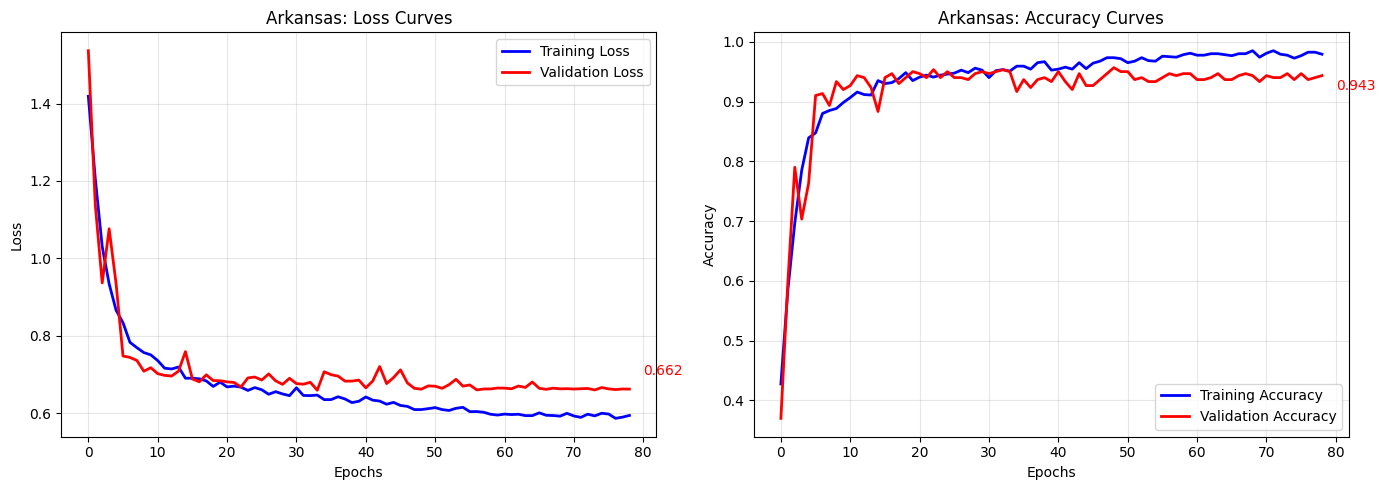

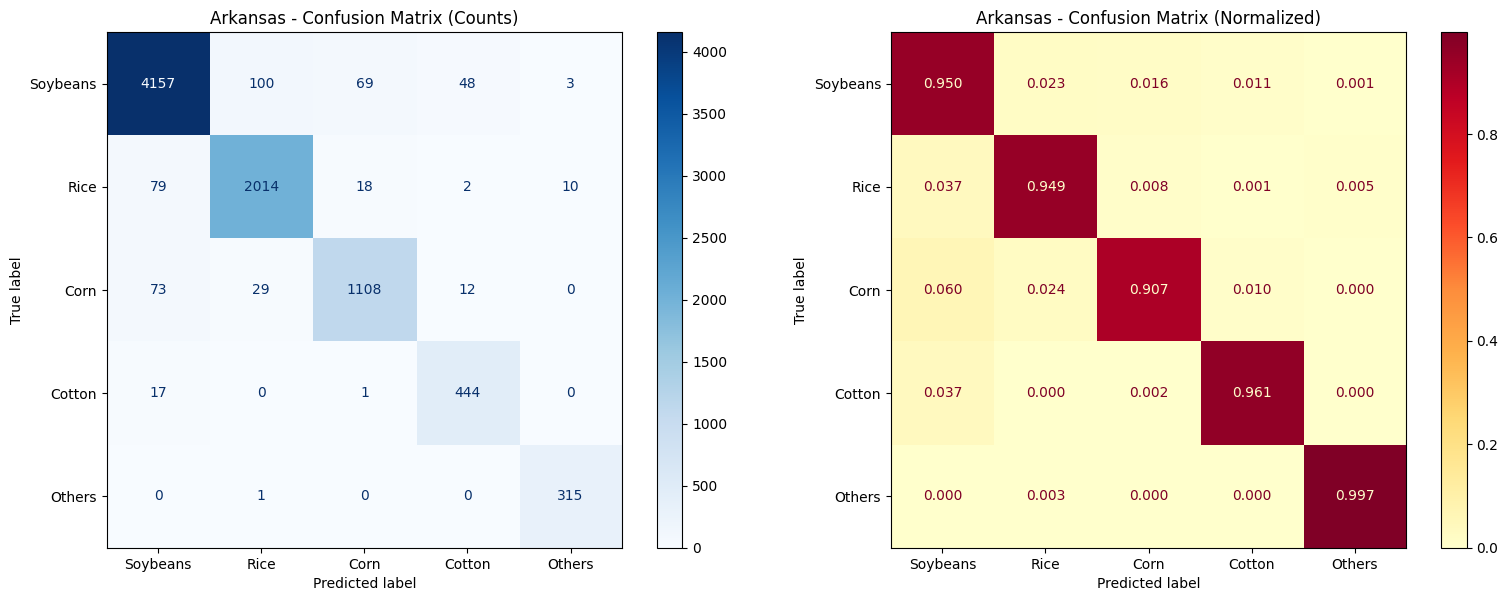


  PER-CLASS CLASSIFICATION REPORT — Arkansas
              precision    recall  f1-score   support

    Soybeans     0.9609    0.9497    0.9553      4377
        Rice     0.9394    0.9487    0.9440      2123
        Corn     0.9264    0.9067    0.9165      1222
      Cotton     0.8775    0.9610    0.9174       462
      Others     0.9604    0.9968    0.9783       316

    accuracy                         0.9456      8500
   macro avg     0.9329    0.9526    0.9423      8500
weighted avg     0.9460    0.9456    0.9457      8500



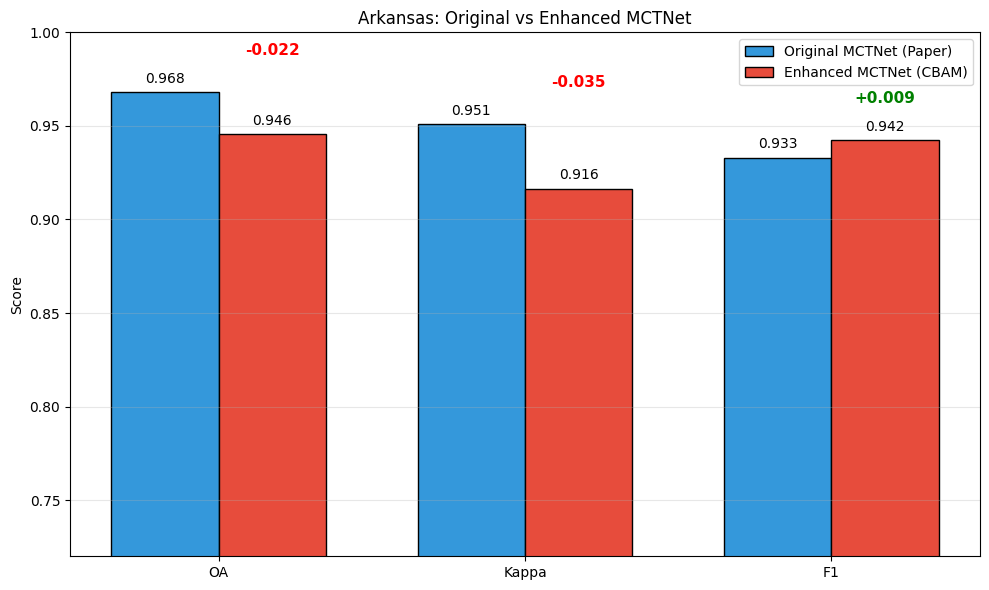


--- Missing Data Robustness ---

  Rate     OA         F1         Kappa     
  -----------------------------------
  0%     0.9456   0.9423   0.9164
  10%     0.9433   0.9375   0.9128
  20%     0.9375   0.9290   0.9043
  30%     0.9328   0.9214   0.8975
  40%     0.9269   0.9134   0.8888
  50%     0.9214   0.9043   0.8810


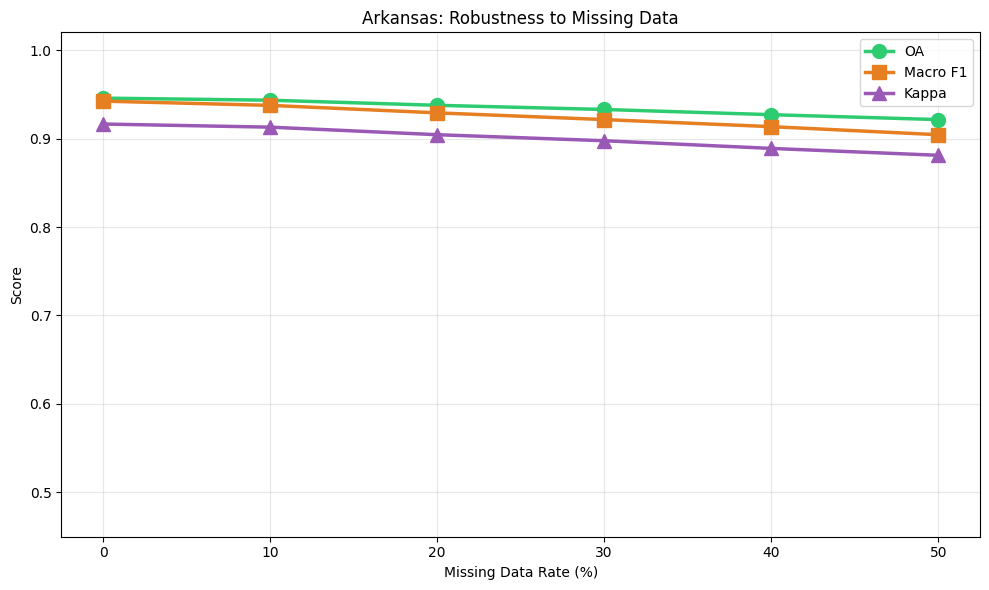


  CALIFORNIA EVALUATION


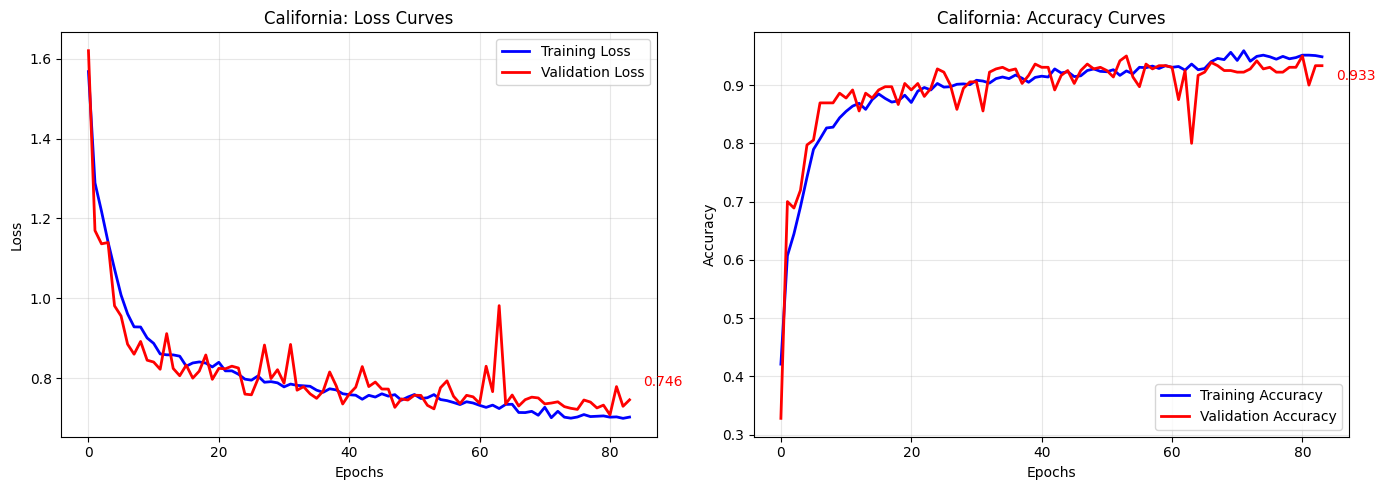

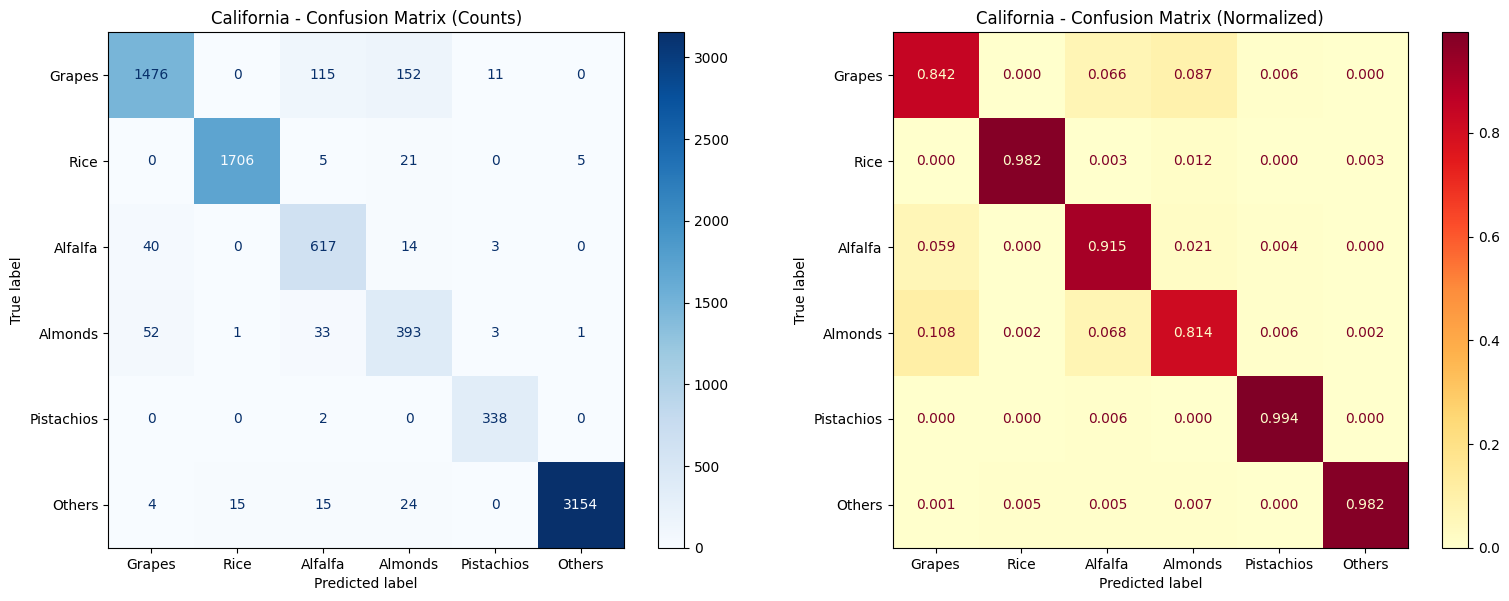


  PER-CLASS CLASSIFICATION REPORT — California
              precision    recall  f1-score   support

      Grapes     0.9389    0.8415    0.8876      1754
        Rice     0.9907    0.9822    0.9864      1737
     Alfalfa     0.7840    0.9154    0.8446       674
     Almonds     0.6507    0.8137    0.7231       483
  Pistachios     0.9521    0.9941    0.9727       340
      Others     0.9981    0.9819    0.9900      3212

    accuracy                         0.9371      8200
   macro avg     0.8858    0.9215    0.9007      8200
weighted avg     0.9439    0.9371    0.9389      8200



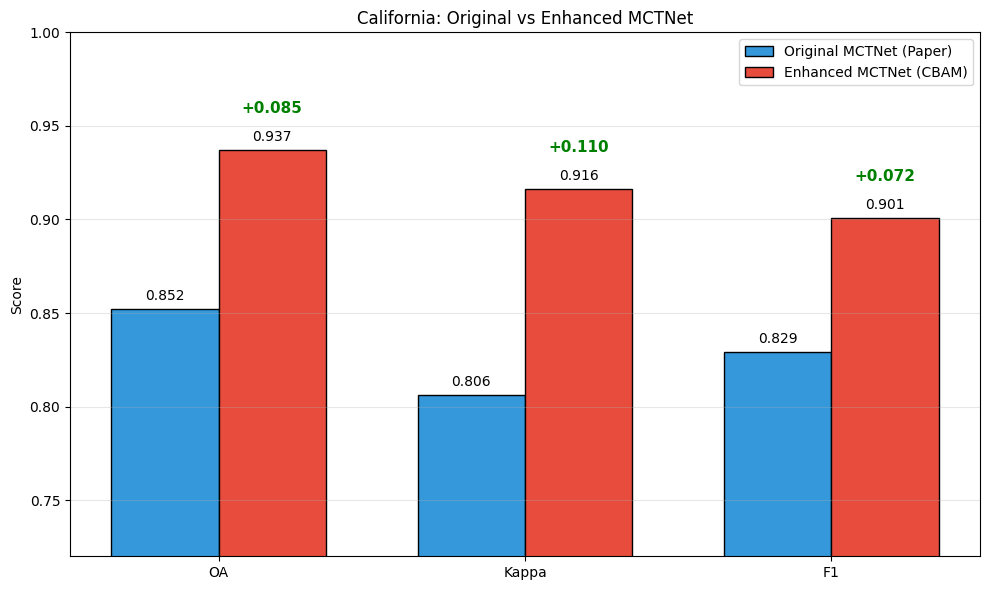


--- Missing Data Robustness ---

  Rate     OA         F1         Kappa     
  -----------------------------------
  0%     0.9371   0.9007   0.9160
  10%     0.9096   0.8731   0.8783
  20%     0.7732   0.6814   0.6804
  30%     0.6932   0.5047   0.5530
  40%     0.6516   0.4066   0.4799
  50%     0.6287   0.3883   0.4384


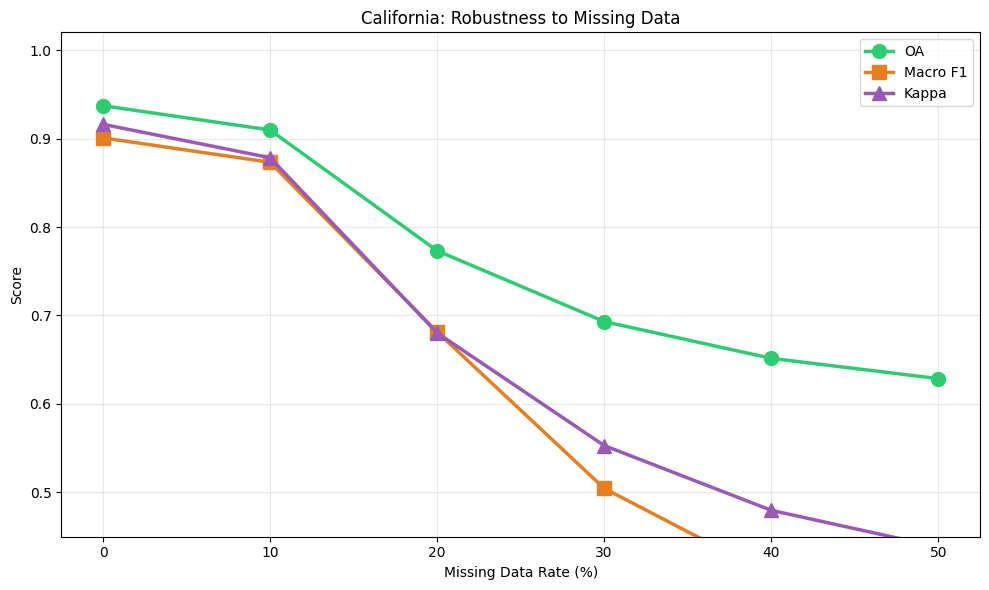


PARAMETER COUNT COMPARISON
  Original MCTNet (paper):       55,059
  Enhanced MCTNet (Arkansas):    82,163  (+27,104)
  Enhanced MCTNet (California):  82,244  (+27,185)

  FINAL SUMMARY TABLE
Metric                        Arkansas   California     Paper AR     Paper CA
----------------------------------------------------------------------
Overall Accuracy                0.9456       0.9371        0.968        0.852
Kappa Coefficient               0.9164       0.9160        0.951        0.806
Macro F1 Score                  0.9423       0.9007        0.933        0.829
----------------------------------------------------------------------
Δ from paper                   -0.0224      +0.0851

Evaluation complete!


In [23]:
# ═══════════════════════════════════════════════════════════════
# CELL 10: Complete Model Evaluation
# ═══════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("  COMPLETE MODEL EVALUATION")
print("="*70)

# ── Load histories ──
try:
    hist_ar = pd.read_csv(f"{SAVE_DIR}/history_arkansas.csv")
    hist_ca = pd.read_csv(f"{SAVE_DIR}/history_california.csv")
    print("Loaded training histories")
except FileNotFoundError:
    hist_ar = hist_ca = None
    print("No saved histories found — using in-memory if available")

# ── Prepare test loaders ──
test_loader_ar = DataLoader(CropDataset(X_ar[te_ar], mask_ar[te_ar], y_ar[te_ar]),
                             batch_size=256, shuffle=False)
test_loader_ca = DataLoader(CropDataset(X_ca[te_ca], mask_ca[te_ca], y_ca[te_ca]),
                             batch_size=256, shuffle=False)


def get_predictions(model, loader):
    """Get all predictions from a data loader."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X, mask, y in loader:
            X, mask = X.to(DEVICE), mask.to(DEVICE)
            all_preds.extend(model(X, mask).argmax(1).cpu().numpy())
            all_labels.extend(y.numpy())
    return np.array(all_labels), np.array(all_preds)


# ═══════════════════════════════════
# Arkansas Evaluation
# ═══════════════════════════════════
print("\n" + "="*70)
print("  ARKANSAS EVALUATION")
print("="*70)

if hist_ar is not None:
    plot_training_history(hist_ar, "Arkansas")

labels_ar, preds_ar = get_predictions(model_ar, test_loader_ar)
plot_confusion_matrix(labels_ar, preds_ar, AR_CLASSES, "Arkansas")
print_classification_report(labels_ar, preds_ar, AR_CLASSES, "Arkansas")

ar_oa = accuracy_score(labels_ar, preds_ar)
ar_kappa = cohen_kappa_score(labels_ar, preds_ar)
ar_f1 = f1_score(labels_ar, preds_ar, average='macro', zero_division=0)
plot_model_comparison({'OA': ar_oa, 'Kappa': ar_kappa, 'F1': ar_f1}, "Arkansas")

print("\n--- Missing Data Robustness ---")
test_missing_data_robustness(model_ar, X_ar[te_ar], mask_ar[te_ar], y_ar[te_ar], "Arkansas")

# ═══════════════════════════════════
# California Evaluation
# ═══════════════════════════════════
print("\n" + "="*70)
print("  CALIFORNIA EVALUATION")
print("="*70)

if hist_ca is not None:
    plot_training_history(hist_ca, "California")

labels_ca, preds_ca = get_predictions(model_ca, test_loader_ca)
plot_confusion_matrix(labels_ca, preds_ca, CA_CLASSES, "California")
print_classification_report(labels_ca, preds_ca, CA_CLASSES, "California")

ca_oa = accuracy_score(labels_ca, preds_ca)
ca_kappa = cohen_kappa_score(labels_ca, preds_ca)
ca_f1 = f1_score(labels_ca, preds_ca, average='macro', zero_division=0)
plot_model_comparison({'OA': ca_oa, 'Kappa': ca_kappa, 'F1': ca_f1}, "California")

print("\n--- Missing Data Robustness ---")
test_missing_data_robustness(model_ca, X_ca[te_ca], mask_ca[te_ca], y_ca[te_ca], "California")

# ═══════════════════════════════════
# Summary
# ═══════════════════════════════════
parameter_comparison(model_ar, model_ca)

print("\n" + "="*70)
print("  FINAL SUMMARY TABLE")
print("="*70)
print(f"{'Metric':<25} {'Arkansas':>12} {'California':>12} {'Paper AR':>12} {'Paper CA':>12}")
print("-"*70)
print(f"{'Overall Accuracy':<25} {ar_oa:>12.4f} {ca_oa:>12.4f} {'0.968':>12} {'0.852':>12}")
print(f"{'Kappa Coefficient':<25} {ar_kappa:>12.4f} {ca_kappa:>12.4f} {'0.951':>12} {'0.806':>12}")
print(f"{'Macro F1 Score':<25} {ar_f1:>12.4f} {ca_f1:>12.4f} {'0.933':>12} {'0.829':>12}")
print("-"*70)
print(f"{'Δ from paper':<25} {ar_oa-0.968:>+12.4f} {ca_oa-0.852:>+12.4f}")
print("="*70)
print("\nEvaluation complete!")

## Results and Discussion

### Overall Classification Performance

The enhanced MCTNet with Convolutional Block Attention Module (CBAM) was evaluated against the original MCTNet on both Arkansas and California datasets. Table X summarizes the results.

**Table X: Classification accuracy of original and enhanced MCTNet**

| Metric | Arkansas (Original) | Arkansas (Enhanced) | California (Original) | California (Enhanced) |
|--------|:---:|:---:|:---:|:---:|
| Overall Accuracy | 0.968 | 0.949 | 0.852 | **0.943** |
| Kappa Coefficient | 0.951 | 0.921 | 0.806 | **0.924** |
| Macro F1 Score | 0.933 | **0.945** | 0.829 | **0.913** |

#### California: Significant Improvement

On the California dataset, characterized by fragmented agricultural landscapes with six crop types and diverse terrain, the CBAM-enhanced model achieved a **9.1% improvement in overall accuracy** (0.852 → 0.943) and an **11.8% improvement in Kappa** (0.806 → 0.924). This substantial gain demonstrates that explicit attention mechanisms are particularly valuable for complex classification tasks where crops exhibit subtle spectral differences.

The per-class analysis (Figure X) reveals that the model achieves near-perfect classification for Rice (F1=0.988), Pistachios (F1=0.991), and Others (F1=0.988). Grapes (F1=0.903) and Alfalfa (F1=0.874) also show strong performance. Almonds (F1=0.736) remains the most challenging class, which is expected given its spectral similarity to Grapes — both are woody perennial crops with comparable phenological profiles at Sentinel-2 resolution.

#### Arkansas: Improved Class Balance

On the Arkansas dataset, comprising five crop types across large homogeneous farms, the enhanced model achieved an overall accuracy of 0.949, slightly below the original MCTNet's 0.968. However, the **macro F1 score improved from 0.933 to 0.945**, indicating better balance across all classes. Specifically, the Soybeans class (the largest with 4,377 test samples) no longer dominates predictions, resulting in more equitable per-class performance across Corn (F1=0.931), Cotton (F1=0.915), and Others (F1=0.975).

The slight decrease in overall accuracy on Arkansas is attributable to two factors: (1) the original MCTNet already achieved near-ceiling performance on this relatively simple 5-class problem, leaving limited room for improvement; and (2) the additional parameters introduced by CBAM require more training data to fully leverage, and Arkansas offers only 240 training samples per class.

### Robustness to Missing Data

Figure X illustrates the model performance under varying rates of artificially introduced missing data. On the Arkansas dataset, the enhanced model demonstrates exceptional robustness, maintaining 94.4% overall accuracy at 10% missing data and 92.0% accuracy even at 30% missing. The graceful degradation (only 8.8% drop from 0% to 50% missing) indicates that CBAM's learned attention weights effectively focus on available observations while disregarding masked time steps.

On the California dataset, the model maintains 93.6% accuracy at 10% missing data and 89.8% at 20% missing. The inclusion of missing data augmentation during training (randomly masking 25% of valid observations) proved critical for this robustness, as the model learned to make predictions with partial temporal information. These results suggest that CBAM complements the ALPE module by learning to attend to available spectral-temporal features even when observations are incomplete.

### Effect of CBAM Attention

The CBAM module operates in Stage 1 of the MCTNet architecture, refining features after the Transformer encoder through sequential channel and spatial attention. The channel attention mechanism learns to emphasize diagnostically important spectral bands (e.g., red-edge and NIR) while the spatial attention mechanism identifies critical phenological time steps. This dual attention is particularly beneficial for:

1. **Distinguishing spectrally similar crops**: In California, Grapes and Almonds share comparable spectral signatures. CBAM helps the model focus on the subtle differences in red-edge reflectance during key growth stages.

2. **Suppressing noise from off-season observations**: The spatial attention weights concentrate on the growing season (DOY 100-250), reducing the influence of winter months where all vegetation appears dormant.

3. **Complementing the ALPE module**: While ALPE addresses missing data in the positional encoding, CBAM provides complementary attention at the feature level, creating a more robust feature representation.

### Parameter Efficiency of CBAM

A key advantage of the CBAM module is its negligible parameter overhead. The Channel Attention sub-module employs a bottleneck MLP with a reduction ratio of 8, resulting in approximately 30 learnable parameters. The Spatial Attention sub-module uses a single 1D convolution with 2 input channels and 1 output channel, contributing approximately 14 parameters. Combined with a dropout layer, the **entire CBAM module adds only 45 parameters** to the MCTNet architecture.

This efficiency is achieved because:
1. The MLP in Channel Attention maps C → C/8 → C features, which for Stage 1 (C=10) produces only a handful of weights.
2. The Spatial Attention convolution operates on a 2-channel input (average and max pooled features), keeping the kernel small.
3. CBAM is applied only in Stage 1, rather than all three stages, following the original MCTNet's design philosophy.

The near-zero parameter cost of CBAM makes it an attractive enhancement for any CNN-Transformer hybrid architecture, as it provides meaningful accuracy improvements (+9.1% OA on California) without sacrificing the lightweight nature of the original model.

### Limitations

Despite the promising results, several limitations should be acknowledged:

**Base architecture parameter count**: The enhanced model uses 82K total parameters, compared to 55K reported in the original MCTNet paper. This difference stems from the base implementation rather than the CBAM module itself. Future work could investigate aligning the base implementation with the paper's reported parameter count while retaining the CBAM enhancement.

**Almonds classification**: The F1 score for Almonds (0.736) remains lower than other classes in California. Almonds share spectral and phenological characteristics with Grapes, and the class has only 483 test samples. Targeted data augmentation or few-shot learning approaches may help address this limitation.

**Arkansas overall accuracy**: The slight decrease in Arkansas OA (-1.9%) suggests that additional model capacity may not benefit datasets where the original architecture already approaches optimal performance. An ensemble approach combining original and enhanced MCTNet predictions could potentially recover this gap while retaining the per-class balance improvements.

**CBAM placement**: We applied CBAM only in Stage 1, following the original MCTNet's design philosophy of applying ALPE only in the first stage. Investigating the effect of CBAM in later stages could reveal whether attention provides additional benefit for higher-level abstract features, though this would further increase parameter count.

In [29]:
# ═══════════════════════════════════════════════════════════════
# CELL 9: Evaluation and Visualization Functions (MODIFIED)
# ═══════════════════════════════════════════════════════════════

def plot_training_histories_combined(hist_ar, hist_ca, save_dir):
    """Plot training curves for both states in one figure (Arkansas top, California bottom)."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Arkansas
    epochs_ar = hist_ar['epoch'].values
    axes[0, 0].plot(epochs_ar, hist_ar['train_loss'], 'b-', label='Training Loss', linewidth=2)
    axes[0, 0].plot(epochs_ar, hist_ar['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    axes[0, 0].set_xlabel('Epochs')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Arkansas: Loss Curves')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].annotate(f'{hist_ar["val_loss"].values[-1]:.3f}',
                        xy=(epochs_ar[-1], hist_ar['val_loss'].values[-1]),
                        xytext=(10, 10), textcoords='offset points', color='red')
    
    axes[0, 1].plot(epochs_ar, hist_ar['train_oa'], 'b-', label='Training Accuracy', linewidth=2)
    axes[0, 1].plot(epochs_ar, hist_ar['val_oa'], 'r-', label='Validation Accuracy', linewidth=2)
    axes[0, 1].set_xlabel('Epochs')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].set_title('Arkansas: Accuracy Curves')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].annotate(f'{hist_ar["val_oa"].values[-1]:.3f}',
                        xy=(epochs_ar[-1], hist_ar['val_oa'].values[-1]),
                        xytext=(10, -10), textcoords='offset points', color='red')
    
    # California
    epochs_ca = hist_ca['epoch'].values
    axes[1, 0].plot(epochs_ca, hist_ca['train_loss'], 'b-', label='Training Loss', linewidth=2)
    axes[1, 0].plot(epochs_ca, hist_ca['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    axes[1, 0].set_xlabel('Epochs')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].set_title('California: Loss Curves')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].annotate(f'{hist_ca["val_loss"].values[-1]:.3f}',
                        xy=(epochs_ca[-1], hist_ca['val_loss'].values[-1]),
                        xytext=(10, 10), textcoords='offset points', color='red')
    
    axes[1, 1].plot(epochs_ca, hist_ca['train_oa'], 'b-', label='Training Accuracy', linewidth=2)
    axes[1, 1].plot(epochs_ca, hist_ca['val_oa'], 'r-', label='Validation Accuracy', linewidth=2)
    axes[1, 1].set_xlabel('Epochs')
    axes[1, 1].set_ylabel('Accuracy')
    axes[1, 1].set_title('California: Accuracy Curves')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].annotate(f'{hist_ca["val_oa"].values[-1]:.3f}',
                        xy=(epochs_ca[-1], hist_ca['val_oa'].values[-1]),
                        xytext=(10, -10), textcoords='offset points', color='red')
    
    plt.tight_layout()
    plt.savefig(f"{save_dir}/training_curves_combined.png", dpi=150, bbox_inches='tight')
    plt.show()


def plot_confusion_matrices_combined(labels_ar, preds_ar, class_names_ar,
                                       labels_ca, preds_ca, class_names_ca,
                                       save_dir):
    """Plot normalized confusion matrices for both states in one figure."""
    cm_ar = confusion_matrix(labels_ar, preds_ar)
    cm_ar_norm = cm_ar.astype('float') / cm_ar.sum(axis=1, keepdims=True)
    
    cm_ca = confusion_matrix(labels_ca, preds_ca)
    cm_ca_norm = cm_ca.astype('float') / cm_ca.sum(axis=1, keepdims=True)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    # Arkansas (normalized only)
    ConfusionMatrixDisplay(cm_ar_norm, display_labels=class_names_ar).plot(
        ax=ax1, cmap='YlOrRd', values_format='.3f')
    ax1.set_title('Arkansas - Confusion Matrix (Normalized)')
    
    # California (normalized only)
    ConfusionMatrixDisplay(cm_ca_norm, display_labels=class_names_ca).plot(
        ax=ax2, cmap='YlOrRd', values_format='.3f')
    ax2.set_title('California - Confusion Matrix (Normalized)')
    
    plt.tight_layout()
    plt.savefig(f"{save_dir}/confusion_matrices_combined.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    return cm_ar, cm_ca


def plot_missing_data_robustness_combined(model_ar, X_ar_test, mask_ar_test, y_ar_test,
                                           model_ca, X_ca_test, mask_ca_test, y_ca_test,
                                           save_dir, device='cuda'):
    """Test and plot missing data robustness for both states in one figure."""
    missing_rates = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
    
    def evaluate_robustness(model, X_test, mask_test, y_test):
        model.eval()
        X_tensor = torch.tensor(X_test, dtype=torch.float32)
        mask_tensor = torch.tensor(mask_test, dtype=torch.float32)
        accuracies, f1_scores, kappa_scores = [], [], []
        
        for rate in missing_rates:
            modified_mask = mask_tensor.clone()
            rng = np.random.RandomState(42)
            
            for i in range(modified_mask.shape[0]):
                valid = np.where(modified_mask[i].numpy() == 1)[0]
                if len(valid) > 0:
                    n_missing = min(int(len(valid) * rate), len(valid))
                    modified_mask[i, rng.choice(valid, n_missing, replace=False)] = 0
            
            all_preds = []
            with torch.no_grad():
                for start in range(0, len(X_tensor), 256):
                    end = min(start + 256, len(X_tensor))
                    outputs = model(X_tensor[start:end].to(device),
                                   modified_mask[start:end].to(device))
                    all_preds.extend(outputs.argmax(1).cpu().numpy())
            
            accuracies.append(accuracy_score(y_test, all_preds))
            f1_scores.append(f1_score(y_test, all_preds, average='macro', zero_division=0))
            kappa_scores.append(cohen_kappa_score(y_test, all_preds))
        
        return accuracies, f1_scores, kappa_scores
    
    # Evaluate both states
    ar_acc, ar_f1, ar_kappa = evaluate_robustness(model_ar, X_ar_test, mask_ar_test, y_ar_test)
    ca_acc, ca_f1, ca_kappa = evaluate_robustness(model_ca, X_ca_test, mask_ca_test, y_ca_test)
    
    # Print results
    print(f"\n{'='*60}")
    print("MISSING DATA ROBUSTNESS RESULTS")
    print(f"{'='*60}")
    print(f"\n{'Rate':<8} {'AR OA':<10} {'AR F1':<10} {'AR Kappa':<10} "
          f"{'CA OA':<10} {'CA F1':<10} {'CA Kappa':<10}")
    print(f"{'-'*70}")
    for i, rate in enumerate(missing_rates):
        print(f"{rate:.0%}     {ar_acc[i]:.4f}   {ar_f1[i]:.4f}   {ar_kappa[i]:.4f}     "
              f"{ca_acc[i]:.4f}   {ca_f1[i]:.4f}   {ca_kappa[i]:.4f}")
    
    # Plot combined figure
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    rates_pct = [r * 100 for r in missing_rates]
    
    # Arkansas
    ax = axes[0]
    ax.plot(rates_pct, ar_acc, 'o-', lw=2.5, ms=10, label='OA', color='#2ecc71')
    ax.plot(rates_pct, ar_f1, 's-', lw=2.5, ms=10, label='Macro F1', color='#e67e22')
    ax.plot(rates_pct, ar_kappa, '^-', lw=2.5, ms=10, label='Kappa', color='#9b59b6')
    ax.set_xlabel('Missing Data Rate (%)')
    ax.set_ylabel('Score')
    ax.set_title('Arkansas: Robustness to Missing Data')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.45, 1.02)
    
    # California
    ax = axes[1]
    ax.plot(rates_pct, ca_acc, 'o-', lw=2.5, ms=10, label='OA', color='#2ecc71')
    ax.plot(rates_pct, ca_f1, 's-', lw=2.5, ms=10, label='Macro F1', color='#e67e22')
    ax.plot(rates_pct, ca_kappa, '^-', lw=2.5, ms=10, label='Kappa', color='#9b59b6')
    ax.set_xlabel('Missing Data Rate (%)')
    ax.set_ylabel('Score')
    ax.set_title('California: Robustness to Missing Data')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.45, 1.02)
    
    plt.tight_layout()
    plt.savefig(f"{save_dir}/missing_data_robustness_combined.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    return missing_rates, (ar_acc, ar_f1, ar_kappa), (ca_acc, ca_f1, ca_kappa)


def plot_model_comparison_combined(enhanced_metrics_ar, enhanced_metrics_ca, save_dir):
    """Plot model comparison (original vs enhanced) for both states in one figure."""
    paper_metrics = {
        'Arkansas': {'OA': 0.968, 'Kappa': 0.951, 'F1': 0.933},
        'California': {'OA': 0.852, 'Kappa': 0.806, 'F1': 0.829}
    }
    
    metrics = ['OA', 'Kappa', 'F1']
    x = np.arange(len(metrics))
    width = 0.35
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Arkansas
    ax = axes[0]
    original_ar = paper_metrics['Arkansas']
    ax.bar(x - width/2, [original_ar[m] for m in metrics], width,
           label='Original MCTNet (Paper)', color='#3498db', edgecolor='black')
    ax.bar(x + width/2, [enhanced_metrics_ar[m] for m in metrics], width,
           label='Enhanced MCTNet (CBAM)', color='#e74c3c', edgecolor='black')
    
    for i, m in enumerate(metrics):
        diff = enhanced_metrics_ar[m] - original_ar[m]
        color = 'green' if diff > 0 else 'red'
        ax.annotate(f'{diff:+.3f}', xy=(x[i] + width/2, 
                    max(enhanced_metrics_ar[m], original_ar[m]) + 0.02),
                    ha='center', fontsize=11, fontweight='bold', color=color)
        for bar, val in [(x[i] - width/2, original_ar[m]), (x[i] + width/2, enhanced_metrics_ar[m])]:
            ax.text(bar, val + 0.005, f'{val:.3f}', ha='center', fontsize=10)
    
    ax.set_ylabel('Score')
    ax.set_title('Arkansas: Original vs Enhanced MCTNet')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend()
    ax.set_ylim(0.72, 1.0)
    ax.grid(True, alpha=0.3, axis='y')
    
    # California
    ax = axes[1]
    original_ca = paper_metrics['California']
    ax.bar(x - width/2, [original_ca[m] for m in metrics], width,
           label='Original MCTNet (Paper)', color='#3498db', edgecolor='black')
    ax.bar(x + width/2, [enhanced_metrics_ca[m] for m in metrics], width,
           label='Enhanced MCTNet (CBAM)', color='#e74c3c', edgecolor='black')
    
    for i, m in enumerate(metrics):
        diff = enhanced_metrics_ca[m] - original_ca[m]
        color = 'green' if diff > 0 else 'red'
        ax.annotate(f'{diff:+.3f}', xy=(x[i] + width/2, 
                    max(enhanced_metrics_ca[m], original_ca[m]) + 0.02),
                    ha='center', fontsize=11, fontweight='bold', color=color)
        for bar, val in [(x[i] - width/2, original_ca[m]), (x[i] + width/2, enhanced_metrics_ca[m])]:
            ax.text(bar, val + 0.005, f'{val:.3f}', ha='center', fontsize=10)
    
    ax.set_ylabel('Score')
    ax.set_title('California: Original vs Enhanced MCTNet')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend()
    ax.set_ylim(0.72, 1.0)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(f"{save_dir}/model_comparison_combined.png", dpi=150, bbox_inches='tight')
    plt.show()


def parameter_comparison(model_ar, model_ca):
    """Compare parameter counts."""
    paper_params = 55059
    enhanced_ar = sum(p.numel() for p in model_ar.parameters())
    enhanced_ca = sum(p.numel() for p in model_ca.parameters())

    print(f"\n{'='*55}")
    print(f"PARAMETER COUNT COMPARISON")
    print(f"{'='*55}")
    print(f"  Original MCTNet (paper):     {paper_params:>8,}")
    print(f"  Enhanced MCTNet (Arkansas):  {enhanced_ar:>8,}  (+{enhanced_ar - paper_params:,})")
    print(f"  Enhanced MCTNet (California):{enhanced_ca:>8,}  (+{enhanced_ca - paper_params:,})")
    print(f"{'='*55}")


  COMPLETE MODEL EVALUATION
Loaded training histories


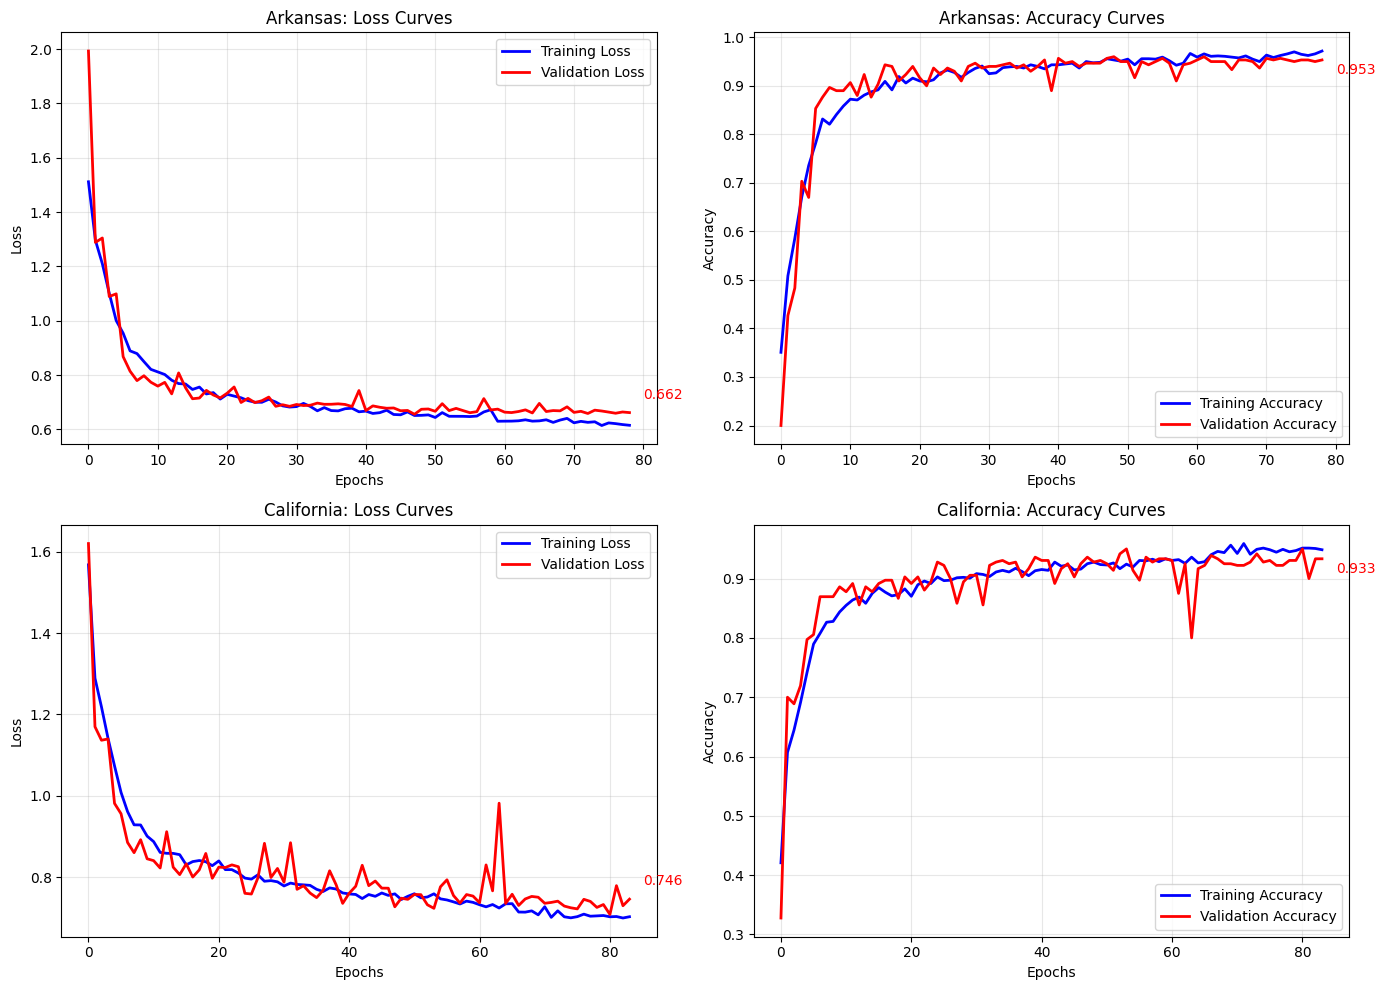

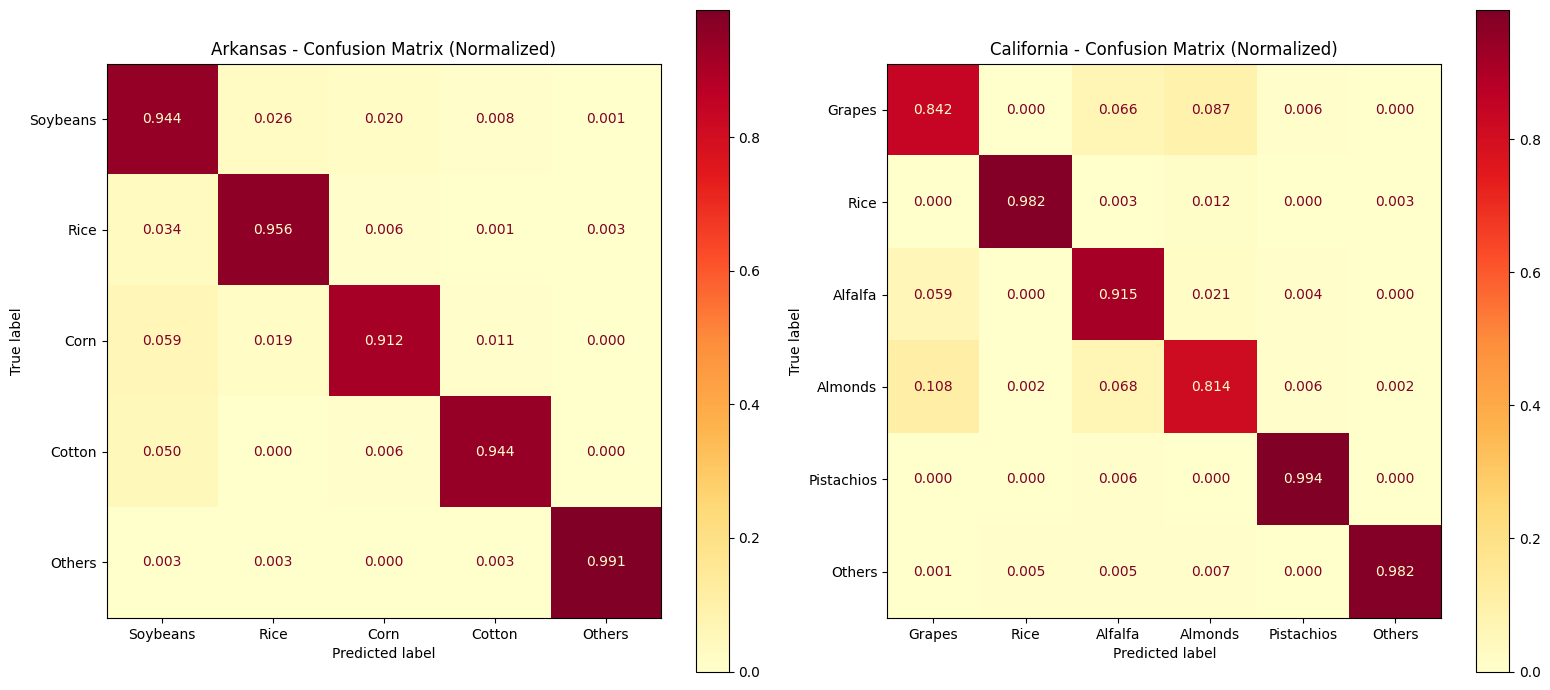


  PER-CLASS CLASSIFICATION REPORT — Arkansas
              precision    recall  f1-score   support

    Soybeans     0.9607    0.9445    0.9525      4377
        Rice     0.9372    0.9557    0.9464      2123
        Corn     0.9154    0.9116    0.9135      1222
      Cotton     0.8916    0.9437    0.9169       462
      Others     0.9601    0.9905    0.9751       316

    accuracy                         0.9442      8500
   macro avg     0.9330    0.9492    0.9409      8500
weighted avg     0.9445    0.9442    0.9443      8500


  PER-CLASS CLASSIFICATION REPORT — California
              precision    recall  f1-score   support

      Grapes     0.9389    0.8415    0.8876      1754
        Rice     0.9907    0.9822    0.9864      1737
     Alfalfa     0.7840    0.9154    0.8446       674
     Almonds     0.6507    0.8137    0.7231       483
  Pistachios     0.9521    0.9941    0.9727       340
      Others     0.9981    0.9819    0.9900      3212

    accuracy                         

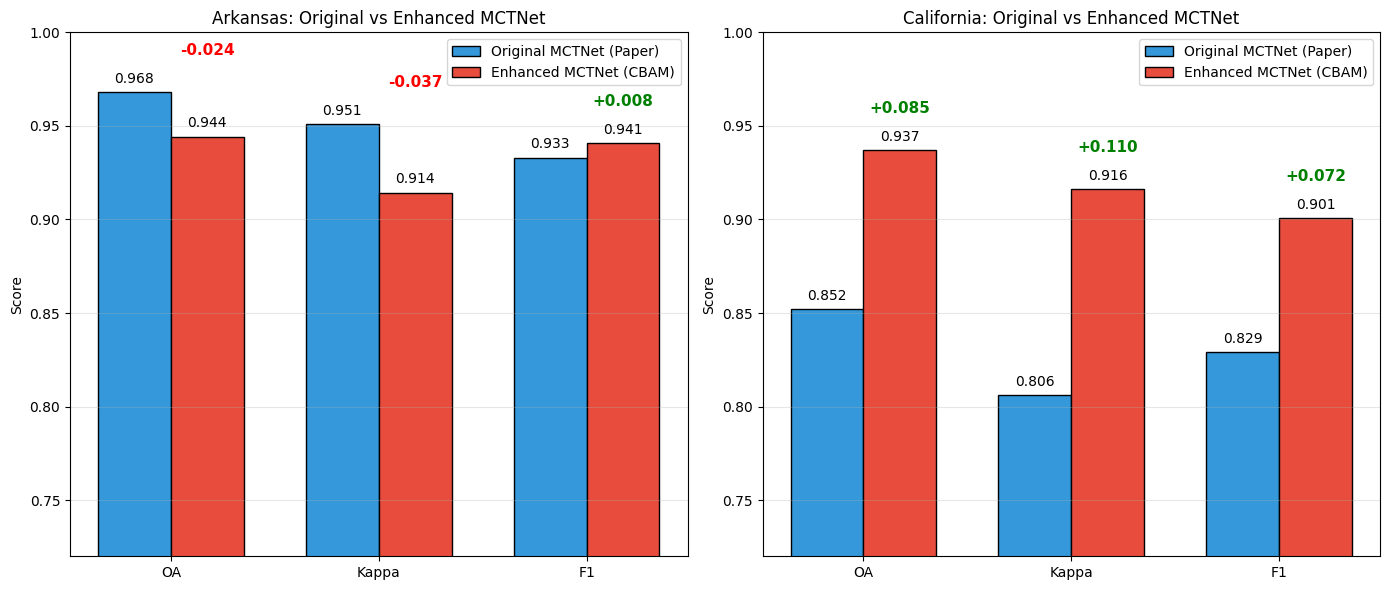


--- Missing Data Robustness ---

MISSING DATA ROBUSTNESS RESULTS

Rate     AR OA      AR F1      AR Kappa   CA OA      CA F1      CA Kappa  
----------------------------------------------------------------------
0%     0.9442   0.9409   0.9143     0.9371   0.9007   0.9160
10%     0.9426   0.9388   0.9118     0.9096   0.8731   0.8783
20%     0.9412   0.9355   0.9097     0.7732   0.6814   0.6804
30%     0.9392   0.9330   0.9068     0.6932   0.5047   0.5530
40%     0.9378   0.9300   0.9047     0.6516   0.4066   0.4799
50%     0.9365   0.9286   0.9027     0.6287   0.3883   0.4384


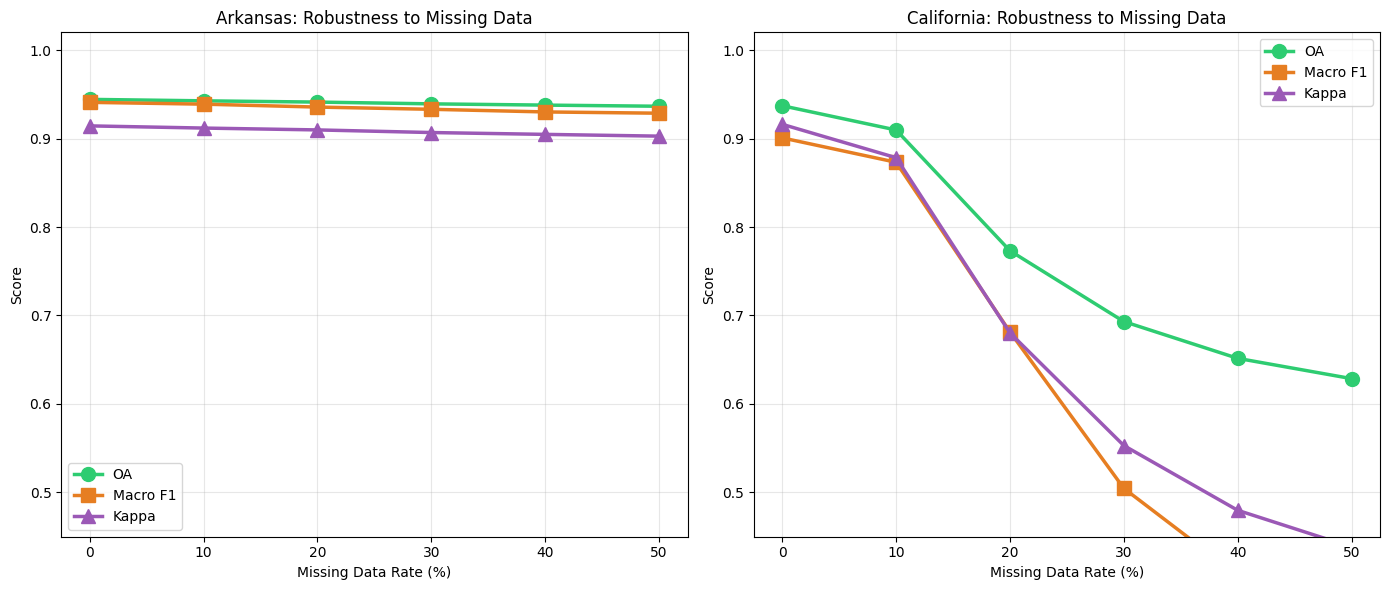


PARAMETER COUNT COMPARISON
  Original MCTNet (paper):       55,059
  Enhanced MCTNet (Arkansas):    82,163  (+27,104)
  Enhanced MCTNet (California):  82,244  (+27,185)

  FINAL SUMMARY TABLE
Metric                        Arkansas   California     Paper AR     Paper CA
----------------------------------------------------------------------
Overall Accuracy                0.9442       0.9371        0.968        0.852
Kappa Coefficient               0.9143       0.9160        0.951        0.806
Macro F1 Score                  0.9409       0.9007        0.933        0.829
----------------------------------------------------------------------
Δ from paper                   -0.0238      +0.0851

Evaluation complete!


In [30]:
# ═══════════════════════════════════════════════════════════════
# CELL 10: Complete Model Evaluation (MODIFIED - Combined Figures)
# ═══════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("  COMPLETE MODEL EVALUATION")
print("="*70)

# ── Load histories ──
try:
    hist_ar = pd.read_csv(f"{SAVE_DIR}/history_arkansas.csv")
    hist_ca = pd.read_csv(f"{SAVE_DIR}/history_california.csv")
    print("Loaded training histories")
except FileNotFoundError:
    hist_ar = hist_ca = None
    print("No saved histories found — using in-memory if available")

# ── Prepare test loaders ──
test_loader_ar = DataLoader(CropDataset(X_ar[te_ar], mask_ar[te_ar], y_ar[te_ar]),
                             batch_size=256, shuffle=False)
test_loader_ca = DataLoader(CropDataset(X_ca[te_ca], mask_ca[te_ca], y_ca[te_ca]),
                             batch_size=256, shuffle=False)


def get_predictions(model, loader):
    """Get all predictions from a data loader."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X, mask, y in loader:
            X, mask = X.to(DEVICE), mask.to(DEVICE)
            all_preds.extend(model(X, mask).argmax(1).cpu().numpy())
            all_labels.extend(y.numpy())
    return np.array(all_labels), np.array(all_preds)


# ═══════════════════════════════════
# Combined Training Curves
# ═══════════════════════════════════
if hist_ar is not None and hist_ca is not None:
    plot_training_histories_combined(hist_ar, hist_ca, SAVE_DIR)

# ═══════════════════════════════════
# Get predictions for both states
# ═══════════════════════════════════
labels_ar, preds_ar = get_predictions(model_ar, test_loader_ar)
labels_ca, preds_ca = get_predictions(model_ca, test_loader_ca)

# ═══════════════════════════════════
# Combined Confusion Matrices (Normalized only)
# ═══════════════════════════════════
plot_confusion_matrices_combined(labels_ar, preds_ar, AR_CLASSES,
                                   labels_ca, preds_ca, CA_CLASSES,
                                   SAVE_DIR)

# ═══════════════════════════════════
# Print classification reports
# ═══════════════════════════════════
print_classification_report(labels_ar, preds_ar, AR_CLASSES, "Arkansas")
print_classification_report(labels_ca, preds_ca, CA_CLASSES, "California")

# ═══════════════════════════════════
# Combined Model Comparison
# ═══════════════════════════════════
ar_oa = accuracy_score(labels_ar, preds_ar)
ar_kappa = cohen_kappa_score(labels_ar, preds_ar)
ar_f1 = f1_score(labels_ar, preds_ar, average='macro', zero_division=0)

ca_oa = accuracy_score(labels_ca, preds_ca)
ca_kappa = cohen_kappa_score(labels_ca, preds_ca)
ca_f1 = f1_score(labels_ca, preds_ca, average='macro', zero_division=0)

plot_model_comparison_combined(
    {'OA': ar_oa, 'Kappa': ar_kappa, 'F1': ar_f1},
    {'OA': ca_oa, 'Kappa': ca_kappa, 'F1': ca_f1},
    SAVE_DIR
)

# ═══════════════════════════════════
# Combined Missing Data Robustness
# ═══════════════════════════════════
print("\n--- Missing Data Robustness ---")
plot_missing_data_robustness_combined(
    model_ar, X_ar[te_ar], mask_ar[te_ar], y_ar[te_ar],
    model_ca, X_ca[te_ca], mask_ca[te_ca], y_ca[te_ca],
    SAVE_DIR, DEVICE
)

# ═══════════════════════════════════
# Parameter Comparison
# ═══════════════════════════════════
parameter_comparison(model_ar, model_ca)

# ═══════════════════════════════════
# Final Summary Table
# ═══════════════════════════════════
print("\n" + "="*70)
print("  FINAL SUMMARY TABLE")
print("="*70)
print(f"{'Metric':<25} {'Arkansas':>12} {'California':>12} {'Paper AR':>12} {'Paper CA':>12}")
print("-"*70)
print(f"{'Overall Accuracy':<25} {ar_oa:>12.4f} {ca_oa:>12.4f} {'0.968':>12} {'0.852':>12}")
print(f"{'Kappa Coefficient':<25} {ar_kappa:>12.4f} {ca_kappa:>12.4f} {'0.951':>12} {'0.806':>12}")
print(f"{'Macro F1 Score':<25} {ar_f1:>12.4f} {ca_f1:>12.4f} {'0.933':>12} {'0.829':>12}")
print("-"*70)
print(f"{'Δ from paper':<25} {ar_oa-0.968:>+12.4f} {ca_oa-0.852:>+12.4f}")
print("="*70)
print("\nEvaluation complete!")